# When2Heat Dataset Exploration - Estonia (EE)

This notebook explores the When2Heat European heating demand dataset, focusing specifically on **Estonia (EE)** data.

## Dataset Overview

The When2Heat dataset provides:
- **Heat demand time series** for space and water heating (2008-2022, hourly)
- **Coefficient of Performance (COP)** for different heat pump types
- Data for 28 European countries
- Heat demand broken down by building type: Single-Family Houses (SFH), Multi-Family Houses (MFH), and Commercial (COM)

**Focus**: Estonian heating profiles and heat pump performance characteristics


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Plot styles
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# Data path
DATA_PATH = Path("example_data/when2heat-european-heating-demand-dataset")

## 1. Load Dataset and Extract Estonia Fields

The main dataset contains data for all 28 European countries. We'll load it and filter for Estonian (EE) fields.


In [ ]:
# Load the main dataset
df = pd.read_csv(DATA_PATH / "when2heat.csv", sep=';', decimal=',')

print(f"Full dataset shape: {df.shape}")
print(f"Total columns: {len(df.columns)}")
print(f"\nFirst few column names:")
print(df.columns[:10].tolist())

# Extract EE (Estonia) columns
timestamp_cols = ['utc_timestamp', 'cet_cest_timestamp']
ee_cols = [col for col in df.columns if col.startswith('EE_')]

print(f"\nEstonia (EE) specific columns: {len(ee_cols)}")
print(f"Time range: {df['utc_timestamp'].min()} to {df['utc_timestamp'].max()}")


Full dataset shape: (131483, 656)
Total columns: 656

First few column names:
['utc_timestamp', 'cet_cest_timestamp', 'AT_COP_ASHP_floor', 'AT_COP_ASHP_radiator', 'AT_COP_ASHP_water', 'AT_COP_GSHP_floor', 'AT_COP_GSHP_radiator', 'AT_COP_GSHP_water', 'AT_COP_WSHP_floor', 'AT_COP_WSHP_radiator']

Estonia (EE) specific columns: 24
Time range: 2007-12-31T22:00:00Z to 2022-12-31T23:00:00Z


In [3]:
# Create Estonia-only dataframe
df_ee = df[timestamp_cols + ee_cols].copy()

# Convert timestamps
df_ee['utc_timestamp'] = pd.to_datetime(df_ee['utc_timestamp'])
df_ee['cet_cest_timestamp'] = pd.to_datetime(df_ee['cet_cest_timestamp'])

print("Estonia Dataset:")
print("=" * 80)
print(f"Shape: {df_ee.shape}")
print(f"Date range: {df_ee['utc_timestamp'].min()} to {df_ee['utc_timestamp'].max()}")
print(f"Duration: {(df_ee['utc_timestamp'].max() - df_ee['utc_timestamp'].min()).days} days")
print(f"\nEstonia columns available:")
for col in ee_cols:
    print(f"  - {col}")


Estonia Dataset:
Shape: (131483, 26)
Date range: 2007-12-31 22:00:00+00:00 to 2022-12-31 23:00:00+00:00
Duration: 5479 days

Estonia columns available:
  - EE_COP_ASHP_floor
  - EE_COP_ASHP_radiator
  - EE_COP_ASHP_water
  - EE_COP_GSHP_floor
  - EE_COP_GSHP_radiator
  - EE_COP_GSHP_water
  - EE_COP_WSHP_floor
  - EE_COP_WSHP_radiator
  - EE_COP_WSHP_water
  - EE_heat_demand_space
  - EE_heat_demand_space_COM
  - EE_heat_demand_space_MFH
  - EE_heat_demand_space_SFH
  - EE_heat_demand_total
  - EE_heat_demand_water
  - EE_heat_demand_water_COM
  - EE_heat_demand_water_MFH
  - EE_heat_demand_water_SFH
  - EE_heat_profile_space_COM
  - EE_heat_profile_space_MFH
  - EE_heat_profile_space_SFH
  - EE_heat_profile_water_COM
  - EE_heat_profile_water_MFH
  - EE_heat_profile_water_SFH


## 2. Data Quality Check

Check for missing values and basic statistics.


In [4]:
# Check missing values
print("Missing Values:")
print("=" * 80)
missing = df_ee[ee_cols].isnull().sum()
if missing.sum() == 0:
    print("No missing values found!")
else:
    print(missing[missing > 0])

print("\n" + "=" * 80)
print("Basic Statistics:")
df_ee[ee_cols].describe()


Missing Values:
EE_heat_demand_space        61361
EE_heat_demand_space_COM    61361
EE_heat_demand_space_MFH    61361
EE_heat_demand_space_SFH    61361
EE_heat_demand_total        61361
EE_heat_demand_water        61361
EE_heat_demand_water_COM    61361
EE_heat_demand_water_MFH    61361
EE_heat_demand_water_SFH    61361
dtype: int64

Basic Statistics:


,EE_COP_ASHP_floor,EE_COP_ASHP_radiator,EE_COP_ASHP_water,EE_COP_GSHP_floor,EE_COP_GSHP_radiator,EE_COP_GSHP_water,EE_COP_WSHP_floor,EE_COP_WSHP_radiator,EE_COP_WSHP_water,EE_heat_demand_space,...,EE_heat_demand_water,EE_heat_demand_water_COM,EE_heat_demand_water_MFH,EE_heat_demand_water_SFH,EE_heat_profile_space_COM,EE_heat_profile_space_MFH,EE_heat_profile_space_SFH,EE_heat_profile_water_COM,EE_heat_profile_water_MFH,EE_heat_profile_water_SFH
count,131483.000000,131483.000000,131483.000000,131483.000000,131483.000000,131483.000000,131483.000000,131483.000000,1.314830e+05,70122.000000,...,70122.000000,70122.000000,70122.000000,70122.000000,131483.000000,131483.000000,131483.000000,131483.000000,131483.000000,131483.000000
mean,3.563169,3.240092,2.477521,5.005681,4.389855,2.927260,5.223933,4.459478,2.800000e+00,808.921351,...,141.260945,29.472747,33.516400,78.258806,113.948039,113.866629,113.876562,114.044112,114.065012,114.062343
std,0.520845,0.715065,0.382615,1.052628,1.354674,0.520531,0.513341,0.903501,6.764837e-12,744.614031,...,58.122400,10.699989,7.387899,43.800431,108.170790,97.848655,104.559722,41.012067,24.786136,63.758563
min,1.460000,1.180000,1.350000,2.340000,1.770000,1.990000,3.310000,1.750000,2.800000e+00,1.000000,...,40.000000,15.000000,16.000000,7.000000,1.000000,1.000000,1.000000,59.000000,56.000000,10.000000
25%,3.210000,2.690000,2.200000,4.080000,3.210000,2.470000,4.860000,3.790000,2.800000e+00,92.000000,...,105.000000,22.000000,31.000000,40.250000,10.000000,17.000000,13.000000,85.000000,105.000000,61.000000
50%,3.680000,3.270000,2.430000,4.930000,4.160000,2.800000,5.190000,4.360000,2.800000e+00,655.000000,...,146.000000,26.000000,35.000000,87.000000,91.000000,99.000000,93.000000,98.000000,121.000000,126.000000
75%,4.060000,4.020000,2.780000,6.190000,5.780000,3.350000,5.640000,5.190000,2.800000e+00,1356.000000,...,174.000000,35.000000,39.000000,103.000000,193.000000,191.000000,192.000000,133.000000,131.000000,148.000000
max,4.060000,4.060000,3.650000,6.340000,6.340000,4.730000,6.120000,6.120000,2.800000e+00,4056.000000,...,279.000000,62.000000,47.000000,187.000000,575.000000,504.000000,572.000000,222.000000,156.000000,264.000000


## 3. Heat Demand Analysis

Exploring Estonian heat demand patterns for space and water heating.


In [5]:
# Identify heat demand columns
heat_demand_cols = [col for col in ee_cols if 'heat_demand' in col and 'profile' not in col]

print("Heat Demand Columns:")
print("=" * 80)
for col in heat_demand_cols:
    mean_val = df_ee[col].mean()
    max_val = df_ee[col].max()
    print(f"{col:40s}: Mean={mean_val:8.2f} MW, Max={max_val:8.2f} MW")

print("\n" + "=" * 80)
print("\nKey Heat Demand Types:")
print(f"Total heat demand: EE_heat_demand_total")
print(f"Space heating: EE_heat_demand_space (broken down by SFH/MFH/COM)")
print(f"Water heating: EE_heat_demand_water (broken down by SFH/MFH/COM)")


Heat Demand Columns:
EE_heat_demand_space                    : Mean=  808.92 MW, Max= 4056.00 MW
EE_heat_demand_space_COM                : Mean=  252.37 MW, Max= 1359.00 MW
EE_heat_demand_space_MFH                : Mean=  167.01 MW, Max=  783.00 MW
EE_heat_demand_space_SFH                : Mean=  389.67 MW, Max= 2055.00 MW
EE_heat_demand_total                    : Mean=  950.19 MW, Max= 4328.00 MW
EE_heat_demand_water                    : Mean=  141.26 MW, Max=  279.00 MW
EE_heat_demand_water_COM                : Mean=   29.47 MW, Max=   62.00 MW
EE_heat_demand_water_MFH                : Mean=   33.52 MW, Max=   47.00 MW
EE_heat_demand_water_SFH                : Mean=   78.26 MW, Max=  187.00 MW


Key Heat Demand Types:
Total heat demand: EE_heat_demand_total
Space heating: EE_heat_demand_space (broken down by SFH/MFH/COM)
Water heating: EE_heat_demand_water (broken down by SFH/MFH/COM)


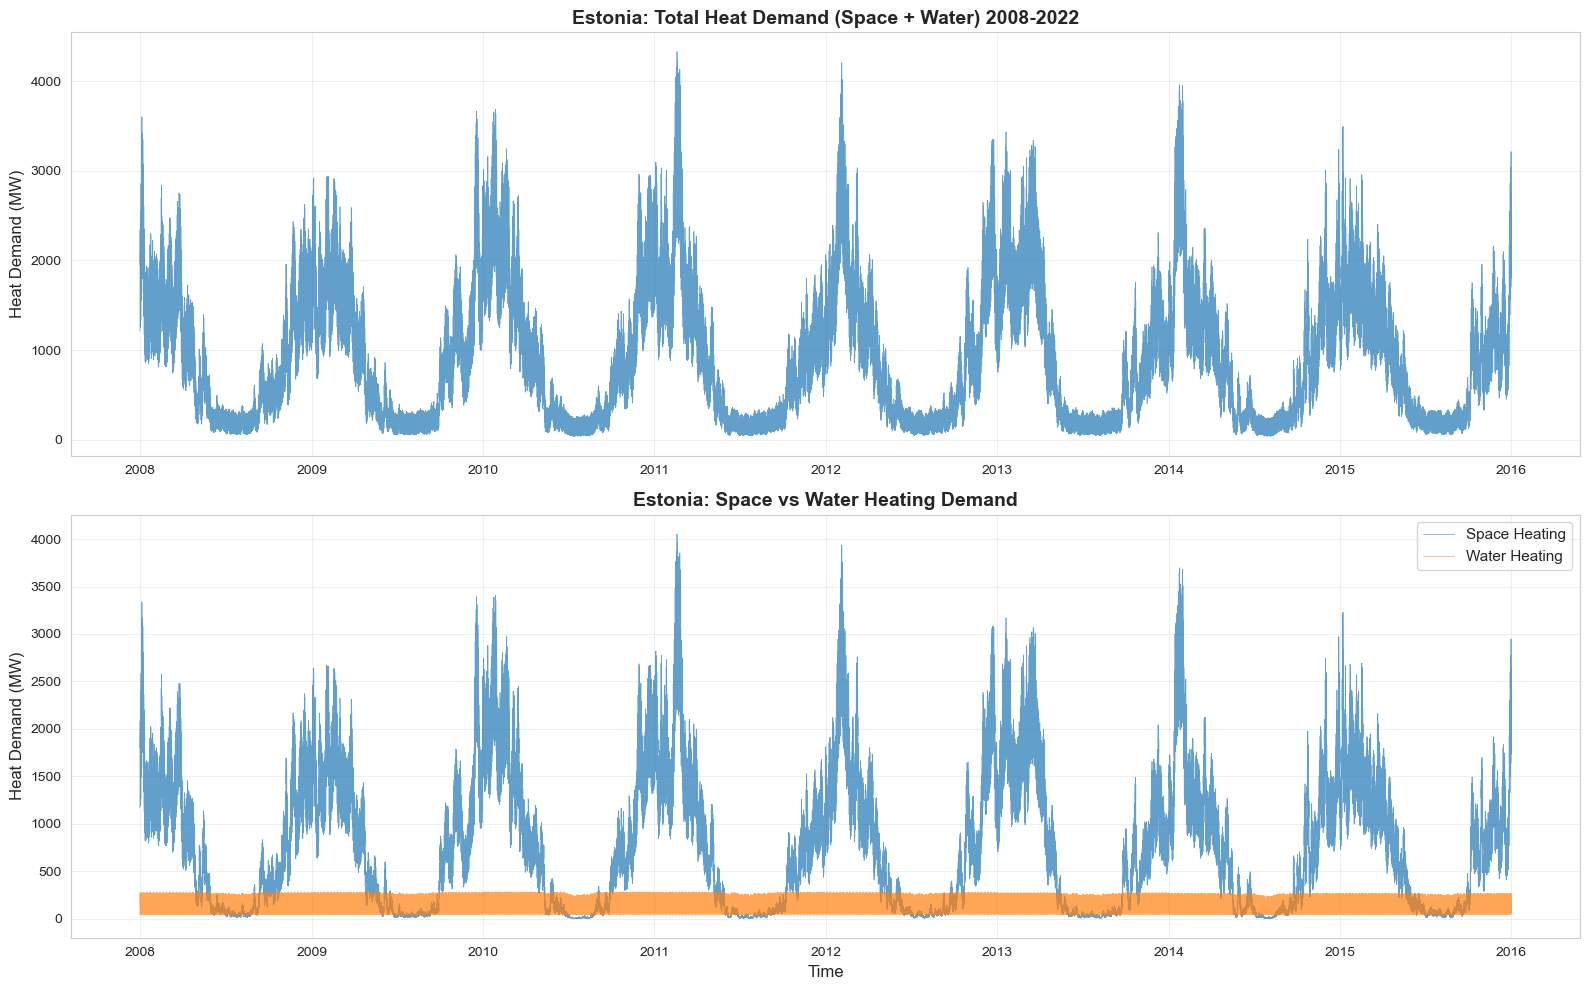

Space heating represents 85.1% of total heat demand
Water heating represents 14.9% of total heat demand


In [6]:
# Visualize total heat demand over time
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Plot 1: Total heat demand time series
axes[0].plot(df_ee['utc_timestamp'], df_ee['EE_heat_demand_total'], linewidth=0.5, alpha=0.7)
axes[0].set_ylabel('Heat Demand (MW)', fontsize=12)
axes[0].set_title('Estonia: Total Heat Demand (Space + Water) 2008-2022', fontsize=14, fontweight='bold')
axes[0].grid(alpha=0.3)

# Plot 2: Space vs Water heating
axes[1].plot(df_ee['utc_timestamp'], df_ee['EE_heat_demand_space'], 
             linewidth=0.5, alpha=0.7, label='Space Heating')
axes[1].plot(df_ee['utc_timestamp'], df_ee['EE_heat_demand_water'], 
             linewidth=0.5, alpha=0.7, label='Water Heating')
axes[1].set_xlabel('Time', fontsize=12)
axes[1].set_ylabel('Heat Demand (MW)', fontsize=12)
axes[1].set_title('Estonia: Space vs Water Heating Demand', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Space heating represents {df_ee['EE_heat_demand_space'].mean() / df_ee['EE_heat_demand_total'].mean() * 100:.1f}% of total heat demand")
print(f"Water heating represents {df_ee['EE_heat_demand_water'].mean() / df_ee['EE_heat_demand_total'].mean() * 100:.1f}% of total heat demand")


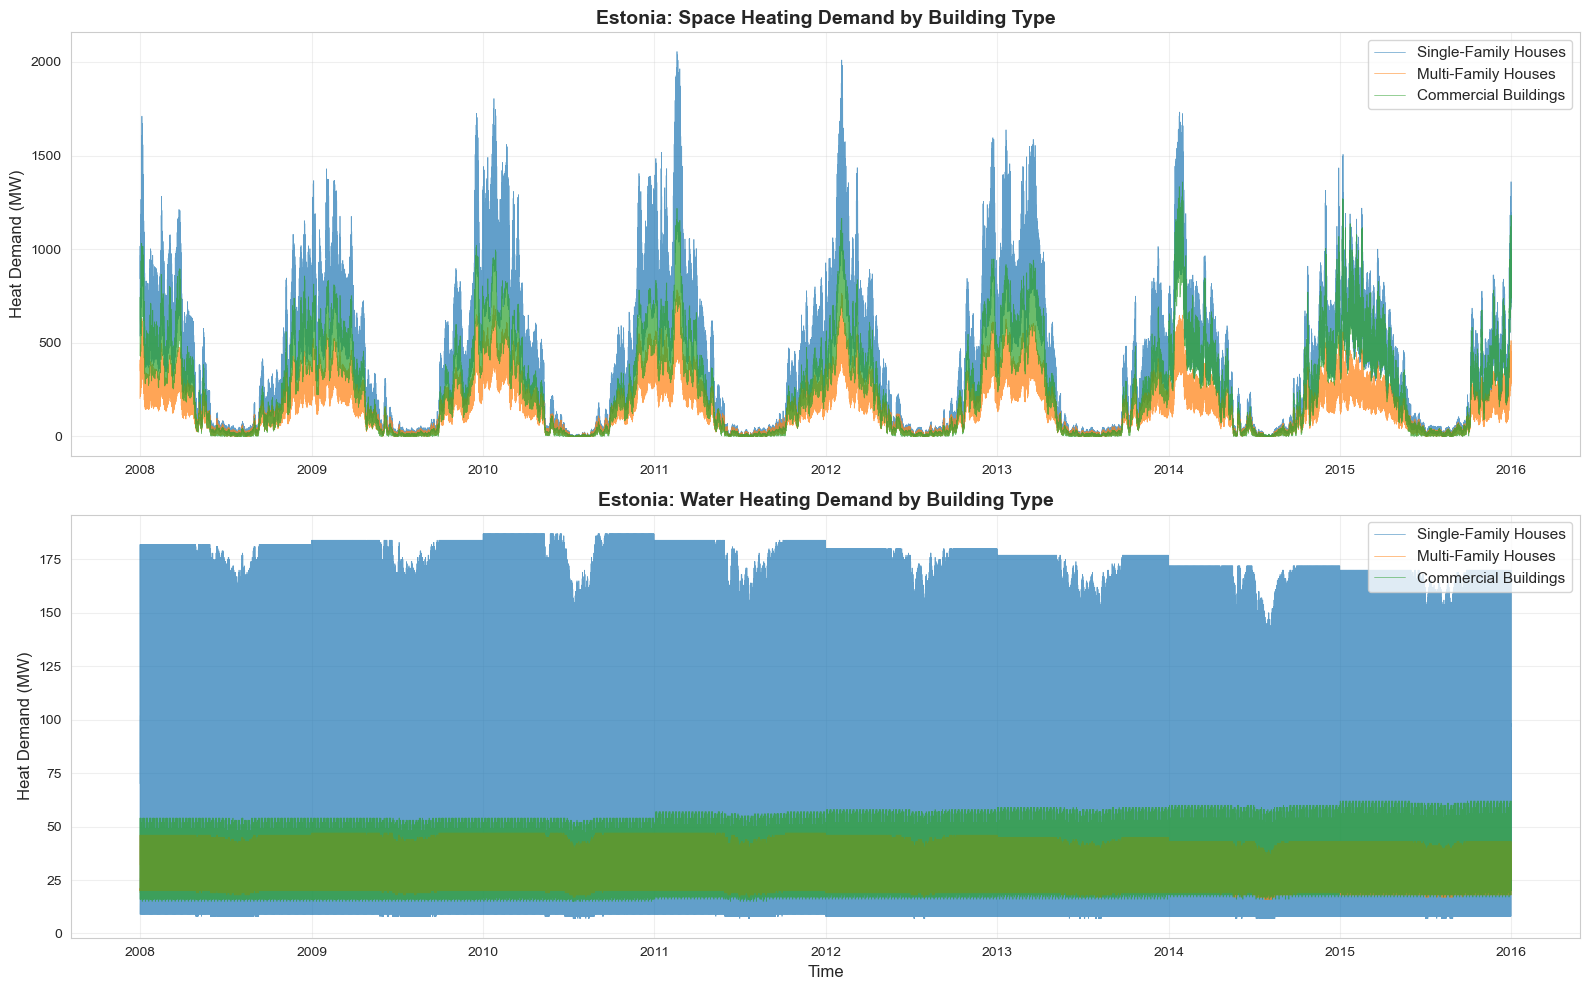

Average Space Heating Distribution by Building Type:
  SFH: 48.2%
  MFH: 20.6%
  COM: 31.2%


In [7]:
# Heat demand by building type
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Space heating by building type
axes[0].plot(df_ee['utc_timestamp'], df_ee['EE_heat_demand_space_SFH'], 
             linewidth=0.5, alpha=0.7, label='Single-Family Houses')
axes[0].plot(df_ee['utc_timestamp'], df_ee['EE_heat_demand_space_MFH'], 
             linewidth=0.5, alpha=0.7, label='Multi-Family Houses')
axes[0].plot(df_ee['utc_timestamp'], df_ee['EE_heat_demand_space_COM'], 
             linewidth=0.5, alpha=0.7, label='Commercial Buildings')
axes[0].set_ylabel('Heat Demand (MW)', fontsize=12)
axes[0].set_title('Estonia: Space Heating Demand by Building Type', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Water heating by building type
axes[1].plot(df_ee['utc_timestamp'], df_ee['EE_heat_demand_water_SFH'], 
             linewidth=0.5, alpha=0.7, label='Single-Family Houses')
axes[1].plot(df_ee['utc_timestamp'], df_ee['EE_heat_demand_water_MFH'], 
             linewidth=0.5, alpha=0.7, label='Multi-Family Houses')
axes[1].plot(df_ee['utc_timestamp'], df_ee['EE_heat_demand_water_COM'], 
             linewidth=0.5, alpha=0.7, label='Commercial Buildings')
axes[1].set_xlabel('Time', fontsize=12)
axes[1].set_ylabel('Heat Demand (MW)', fontsize=12)
axes[1].set_title('Estonia: Water Heating Demand by Building Type', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print percentages
print("Average Space Heating Distribution by Building Type:")
total_space = df_ee['EE_heat_demand_space'].mean()
print(f"  SFH: {df_ee['EE_heat_demand_space_SFH'].mean() / total_space * 100:.1f}%")
print(f"  MFH: {df_ee['EE_heat_demand_space_MFH'].mean() / total_space * 100:.1f}%")
print(f"  COM: {df_ee['EE_heat_demand_space_COM'].mean() / total_space * 100:.1f}%")


## 4. Coefficient of Performance (COP) Analysis

Analyzing heat pump efficiency for different heat sources and heating systems in Estonia.


In [8]:
# Identify COP columns
cop_cols = [col for col in ee_cols if 'COP' in col]

print("COP Columns:")
print("=" * 80)
for col in cop_cols:
    mean_val = df_ee[col].mean()
    min_val = df_ee[col].min()
    max_val = df_ee[col].max()
    print(f"{col:30s}: Mean={mean_val:.3f}, Min={min_val:.3f}, Max={max_val:.3f}")

print("\n" + "=" * 80)
print("\nHeat Pump Types:")
print("  ASHP = Air-Source Heat Pump")
print("  GSHP = Ground-Source Heat Pump")
print("  WSHP = Groundwater-Source Heat Pump")
print("\nHeating Systems:")
print("  floor = Floor heating")
print("  radiator = Radiator heating")
print("  water = Water heating")


COP Columns:
EE_COP_ASHP_floor             : Mean=3.563, Min=1.460, Max=4.060
EE_COP_ASHP_radiator          : Mean=3.240, Min=1.180, Max=4.060
EE_COP_ASHP_water             : Mean=2.478, Min=1.350, Max=3.650
EE_COP_GSHP_floor             : Mean=5.006, Min=2.340, Max=6.340
EE_COP_GSHP_radiator          : Mean=4.390, Min=1.770, Max=6.340
EE_COP_GSHP_water             : Mean=2.927, Min=1.990, Max=4.730
EE_COP_WSHP_floor             : Mean=5.224, Min=3.310, Max=6.120
EE_COP_WSHP_radiator          : Mean=4.459, Min=1.750, Max=6.120
EE_COP_WSHP_water             : Mean=2.800, Min=2.800, Max=2.800


Heat Pump Types:
  ASHP = Air-Source Heat Pump
  GSHP = Ground-Source Heat Pump
  WSHP = Groundwater-Source Heat Pump

Heating Systems:
  floor = Floor heating
  radiator = Radiator heating
  water = Water heating


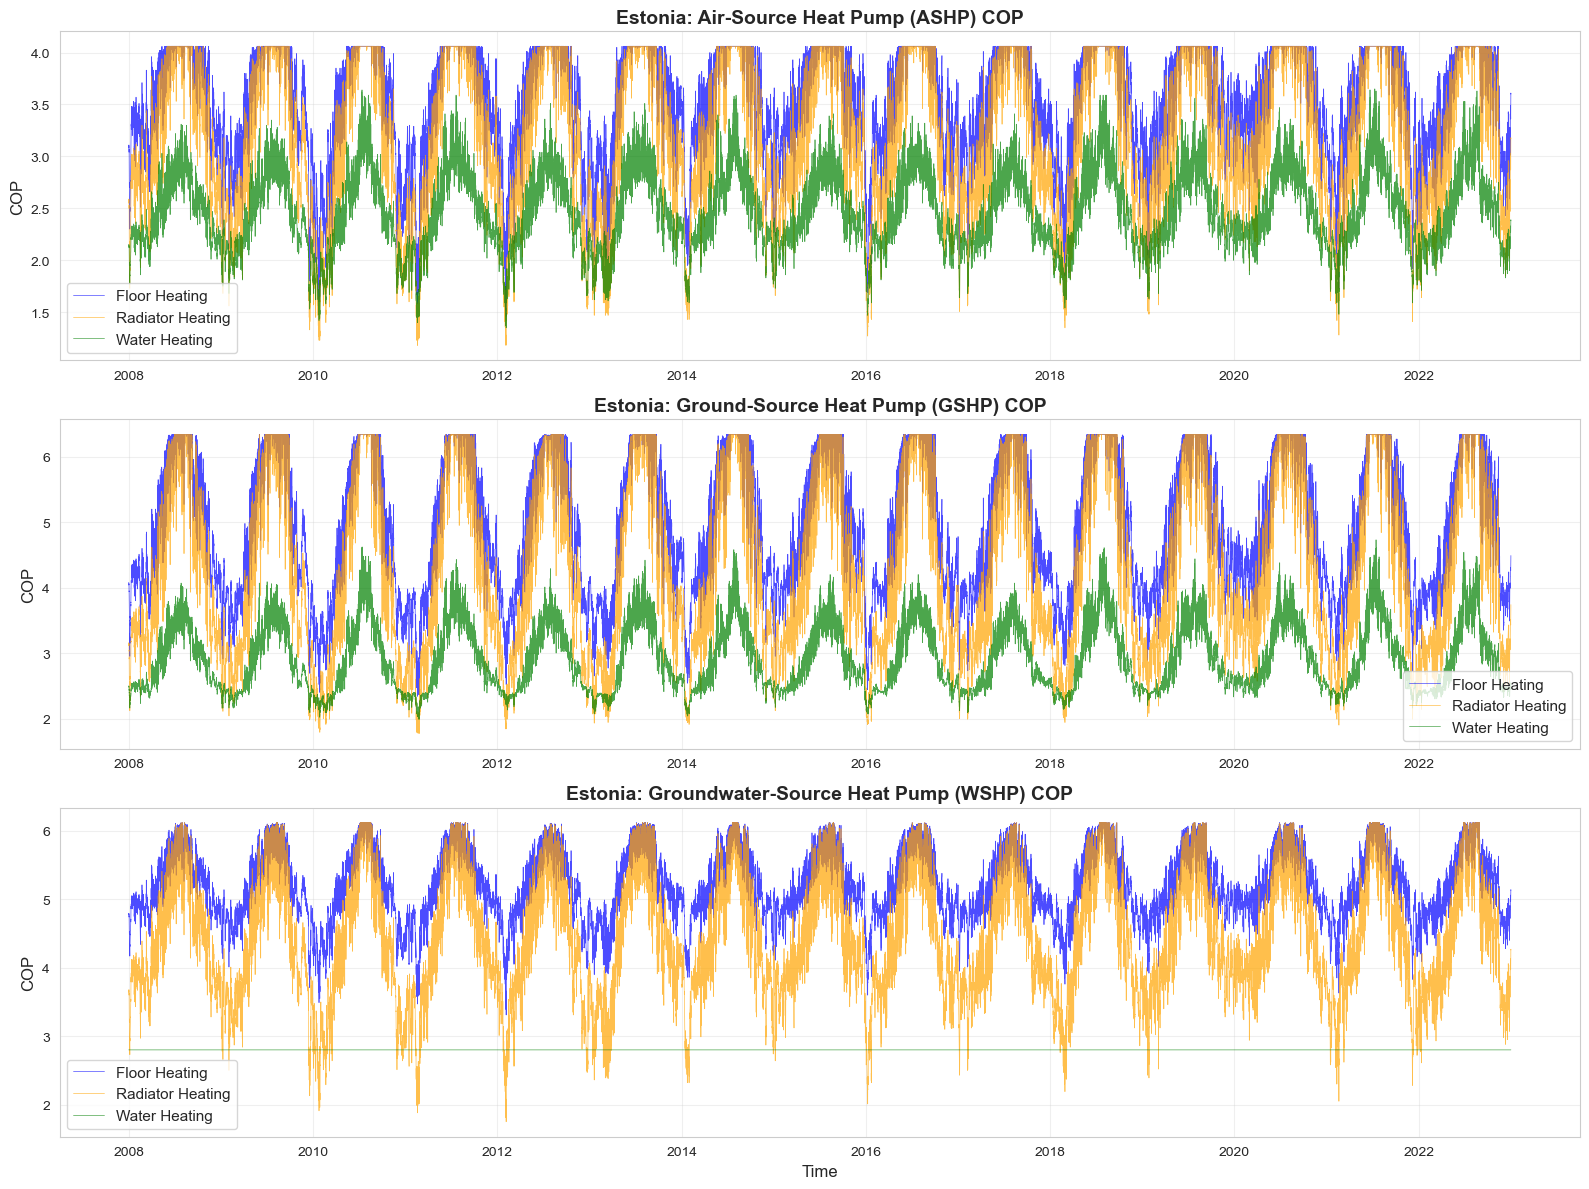

In [9]:
# Visualize COP for different heat pump types (floor heating)
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Plot 1: Air-Source Heat Pumps (ASHP)
axes[0].plot(df_ee['utc_timestamp'], df_ee['EE_COP_ASHP_floor'], 
             linewidth=0.5, alpha=0.7, label='Floor Heating', color='blue')
axes[0].plot(df_ee['utc_timestamp'], df_ee['EE_COP_ASHP_radiator'], 
             linewidth=0.5, alpha=0.7, label='Radiator Heating', color='orange')
axes[0].plot(df_ee['utc_timestamp'], df_ee['EE_COP_ASHP_water'], 
             linewidth=0.5, alpha=0.7, label='Water Heating', color='green')
axes[0].set_ylabel('COP', fontsize=12)
axes[0].set_title('Estonia: Air-Source Heat Pump (ASHP) COP', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Plot 2: Ground-Source Heat Pumps (GSHP)
axes[1].plot(df_ee['utc_timestamp'], df_ee['EE_COP_GSHP_floor'], 
             linewidth=0.5, alpha=0.7, label='Floor Heating', color='blue')
axes[1].plot(df_ee['utc_timestamp'], df_ee['EE_COP_GSHP_radiator'], 
             linewidth=0.5, alpha=0.7, label='Radiator Heating', color='orange')
axes[1].plot(df_ee['utc_timestamp'], df_ee['EE_COP_GSHP_water'], 
             linewidth=0.5, alpha=0.7, label='Water Heating', color='green')
axes[1].set_ylabel('COP', fontsize=12)
axes[1].set_title('Estonia: Ground-Source Heat Pump (GSHP) COP', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

# Plot 3: Groundwater-Source Heat Pumps (WSHP)
axes[2].plot(df_ee['utc_timestamp'], df_ee['EE_COP_WSHP_floor'], 
             linewidth=0.5, alpha=0.7, label='Floor Heating', color='blue')
axes[2].plot(df_ee['utc_timestamp'], df_ee['EE_COP_WSHP_radiator'], 
             linewidth=0.5, alpha=0.7, label='Radiator Heating', color='orange')
axes[2].plot(df_ee['utc_timestamp'], df_ee['EE_COP_WSHP_water'], 
             linewidth=0.5, alpha=0.7, label='Water Heating', color='green')
axes[2].set_xlabel('Time', fontsize=12)
axes[2].set_ylabel('COP', fontsize=12)
axes[2].set_title('Estonia: Groundwater-Source Heat Pump (WSHP) COP', fontsize=14, fontweight='bold')
axes[2].legend(fontsize=11)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


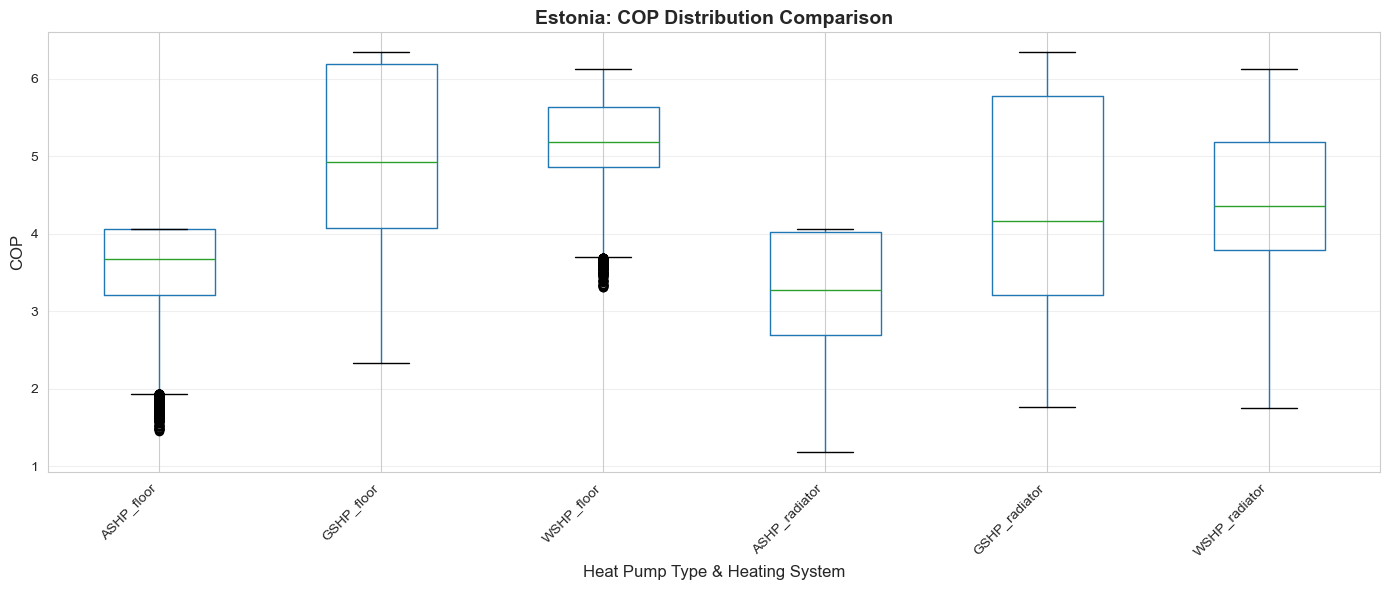

Average COP by Heat Pump Type and System:
ASHP_floor          : 3.563
GSHP_floor          : 5.006
WSHP_floor          : 5.224
ASHP_radiator       : 3.240
GSHP_radiator       : 4.390
WSHP_radiator       : 4.459


In [10]:
# Compare COP distributions
fig, ax = plt.subplots(1, 1, figsize=(14, 6))

cop_comparison = pd.DataFrame({
    'ASHP_floor': df_ee['EE_COP_ASHP_floor'],
    'GSHP_floor': df_ee['EE_COP_GSHP_floor'],
    'WSHP_floor': df_ee['EE_COP_WSHP_floor'],
    'ASHP_radiator': df_ee['EE_COP_ASHP_radiator'],
    'GSHP_radiator': df_ee['EE_COP_GSHP_radiator'],
    'WSHP_radiator': df_ee['EE_COP_WSHP_radiator'],
})

cop_comparison.boxplot(ax=ax)
ax.set_ylabel('COP', fontsize=12)
ax.set_xlabel('Heat Pump Type & Heating System', fontsize=12)
ax.set_title('Estonia: COP Distribution Comparison', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3, axis='y')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Average COP by Heat Pump Type and System:")
print("=" * 80)
for col in cop_comparison.columns:
    print(f"{col:20s}: {cop_comparison[col].mean():.3f}")
